Explaining account at index 2
Actual label:    Real
Predicted label: Real
Bot probability: 0.00%


c:\Users\SEKINA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\SEKINA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


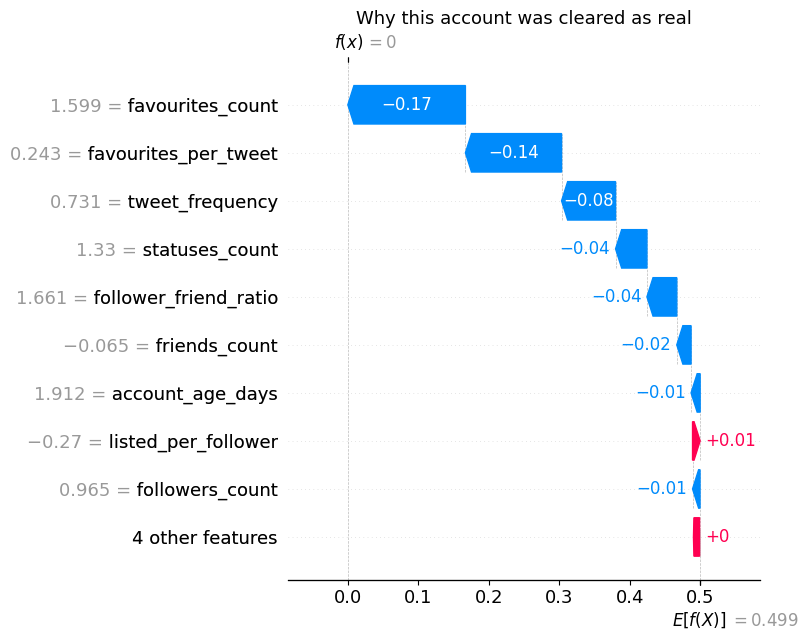

Saved to models/shap_waterfall_real.png


In [15]:

real_idx = np.where(y_test == 0)[0][0]

print(f"Explaining account at index {real_idx}")
print(f"Actual label:    {'Fake' if y_test[real_idx] == 1 else 'Real'}")
print(f"Predicted label: {'Fake' if model.predict(X_test_df.iloc[[real_idx]])[0] == 1 else 'Real'}")
print(f"Bot probability: {model.predict_proba(X_test_df.iloc[[real_idx]])[0][1]:.2%}")

explanation_real = shap.Explanation(
    values=shap_fake[real_idx],
    base_values=explainer.expected_value[1],
    data=X_test_df.iloc[real_idx].values,
    feature_names=feature_columns
)

plt.figure(figsize=(10, 5))
shap.waterfall_plot(explanation_real, show=False)
plt.title("Why this account was cleared as real", fontsize=13)
plt.tight_layout()
plt.savefig("../models/shap_waterfall_real.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to models/shap_waterfall_real.png")

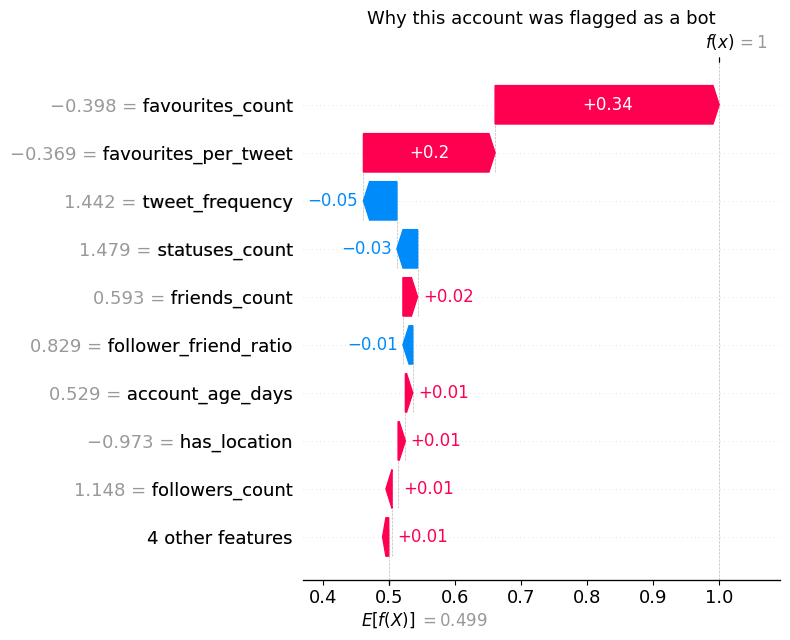

Saved to models/shap_waterfall_fake.png


In [14]:

explanation = shap.Explanation(
    values=shap_fake[fake_idx],
    base_values=explainer.expected_value[1],
    data=X_test_df.iloc[fake_idx].values,
    feature_names=feature_columns
)

plt.figure(figsize=(10, 5))
shap.waterfall_plot(explanation, show=False)
plt.title("Why this account was flagged as a bot", fontsize=13)
plt.tight_layout()
plt.savefig("../models/shap_waterfall_fake.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to models/shap_waterfall_fake.png")

In [13]:

fake_idx = np.where(y_test == 1)[0][0]

print(f"Explaining account at index {fake_idx}")
print(f"Actual label:    {'Fake' if y_test[fake_idx] == 1 else 'Real'}")
print(f"Predicted label: {'Fake' if model.predict(X_test_df.iloc[[fake_idx]])[0] == 1 else 'Real'}")
print(f"Bot probability: {model.predict_proba(X_test_df.iloc[[fake_idx]])[0][1]:.2%}")
print()
print("Feature values for this account:")
print(X_test_df.iloc[fake_idx].round(3))

Explaining account at index 0
Actual label:    Fake
Predicted label: Fake
Bot probability: 100.00%

Feature values for this account:
statuses_count           1.479
followers_count          1.148
friends_count            0.593
favourites_count        -0.398
listed_count             1.079
follower_friend_ratio    0.829
tweet_frequency          1.442
favourites_per_tweet    -0.369
listed_per_follower     -0.067
has_description          0.901
has_url                 -0.440
has_location            -0.973
account_age_days         0.529
Name: 0, dtype: float64


c:\Users\SEKINA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\SEKINA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


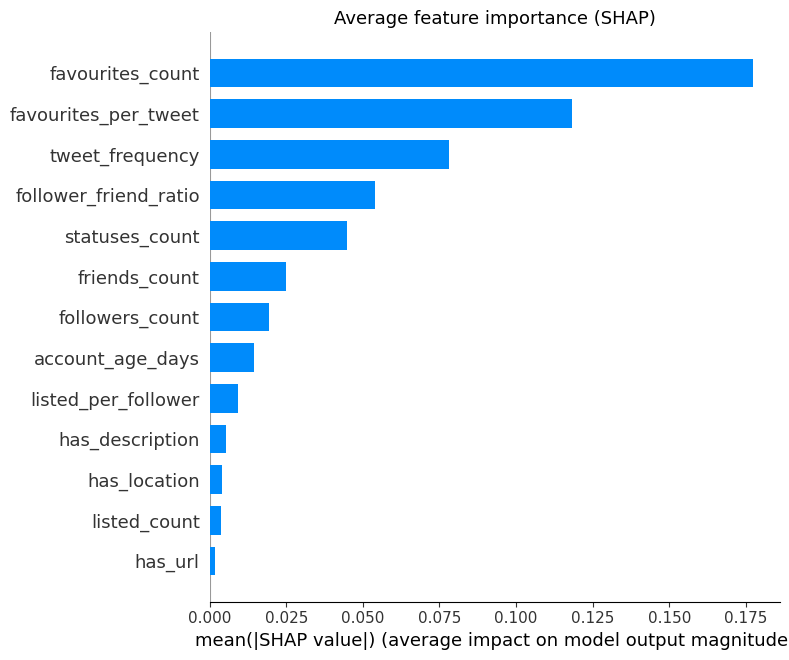

Saved to models/shap_bar.png


In [12]:

plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_fake,
    X_test_df,
    feature_names=feature_columns,
    plot_type="bar",
    show=False
)
plt.title("Average feature importance (SHAP)", fontsize=13)
plt.tight_layout()
plt.savefig("../models/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to models/shap_bar.png")

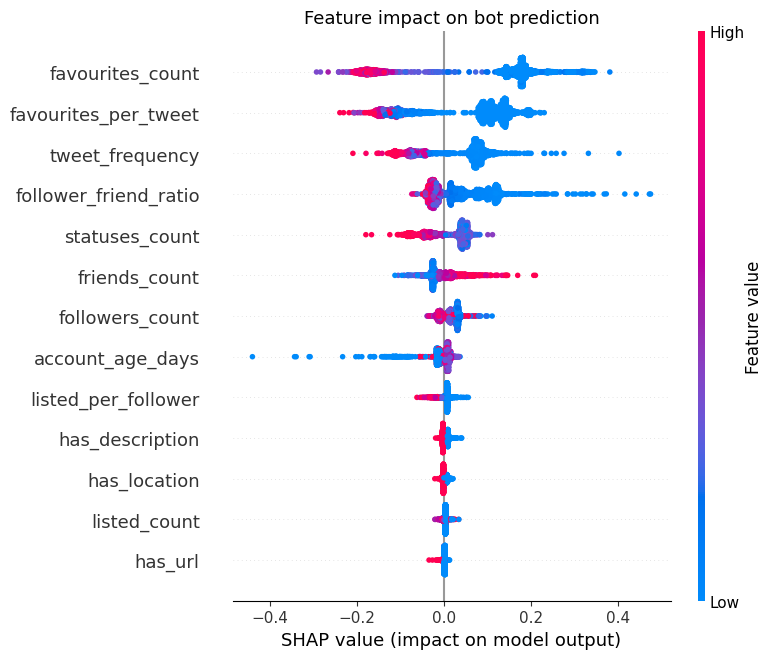

Saved to models/shap_summary.png


In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_fake,
    X_test_df,
    feature_names=feature_columns,
    show=False
)
plt.title("Feature impact on bot prediction", fontsize=13)
plt.tight_layout()
plt.savefig("../models/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to models/shap_summary.png")

In [10]:

print("Creating SHAP explainer (this takes a moment)...")

explainer = shap.TreeExplainer(model)


if isinstance(shap_values, list):
    # Old SHAP format
    shap_fake = shap_values[1]
    expected_val = explainer.expected_value[1]
else:
    # New SHAP format — 3D array
    shap_fake = shap_values[:, :, 1]
    expected_val = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value

print("shap_fake shape:", shap_fake.shape)
print("Expected value:", expected_val)

print("SHAP values computed. Shape:", shap_fake.shape)

Creating SHAP explainer (this takes a moment)...
shap_fake shape: (2548, 13)
Expected value: 0.49914779895365735
SHAP values computed. Shape: (2548, 13)


In [5]:
# If shap isn't installed yet, uncomment the line below and run it once
# !pip install shap

import shap
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Load our trained model and the test data
model = joblib.load("../models/random_forest_model.joblib")

X_test  = np.load("../data/X_test.npy")
y_test  = np.load("../data/y_test.npy")

feature_columns = pd.read_csv("../data/feature_columns.csv").squeeze().tolist()

# Wrap X_test in a DataFrame so SHAP can use the feature names in charts
X_test_df = pd.DataFrame(X_test, columns=feature_columns)

print("Loaded. Test set shape:", X_test_df.shape)

c:\Users\SEKINA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded. Test set shape: (2548, 13)


In [4]:
! pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 217.8 kB/s eta 0:00:36
   -- ------------------------------------- 0.5/8.3 MB 217.8 kB/s eta 0:00:36
   -- ------------------------------------- 0.5/8.3 MB 217.8 kB/s eta 0:00:36
   -- ------------------------------------- 0.5/8.3 MB 217.8 kB/s eta 0:00:36
   --- ------------------------------------ 0.8/8.3 MB 256.6 kB/s e

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
! pip install shap

   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ------------------ --------------------- 262.1/559.2 kB ? eta -:--:--
   ------------------ --------------------- 262.1/559.2 kB ? eta -:--:--
  

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
print("hello world")

hello world
